In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("student_dataset.csv")
df.head()

,Gender,Study_Hours,Attendance,Math_Score,Reading_Score,Writing_Score
0,Male,5,55,48,77,51
1,Female,7,99,90,46,74
2,Male,1,59,87,77,96
3,Male,3,54,47,77,91
4,Male,2,72,89,85,46


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Gender         500 non-null    object
 1   Study_Hours    500 non-null    int64 
 2   Attendance     500 non-null    int64 
 3   Math_Score     500 non-null    int64 
 4   Reading_Score  500 non-null    int64 
 5   Writing_Score  500 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 23.6+ KB


In [4]:
df.describe()

,Study_Hours,Attendance,Math_Score,Reading_Score,Writing_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,4.850000,74.580000,70.204000,72.066000,69.042000
std,2.567623,14.190502,17.217528,16.155607,16.536237
min,1.000000,50.000000,40.000000,45.000000,42.000000
25%,3.000000,62.000000,55.000000,57.750000,55.000000
50%,5.000000,75.000000,70.000000,72.000000,69.000000
75%,7.000000,86.250000,85.000000,86.000000,82.000000
max,9.000000,99.000000,99.000000,99.000000,99.000000


In [5]:
df.isnull().sum()

Gender           0
Study_Hours      0
Attendance       0
Math_Score       0
Reading_Score    0
Writing_Score    0
dtype: int64

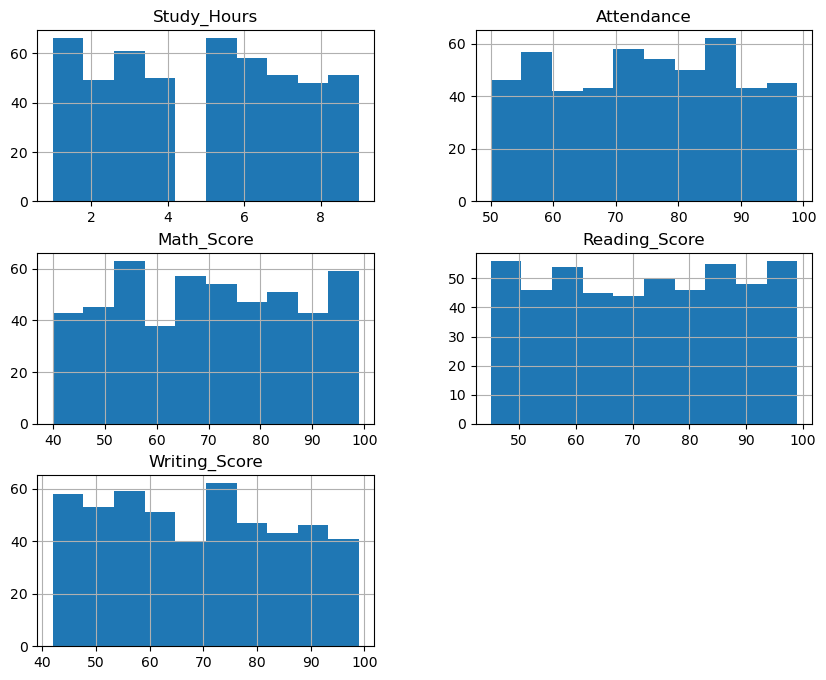

In [6]:
df.hist(figsize=(10,8))
plt.show()

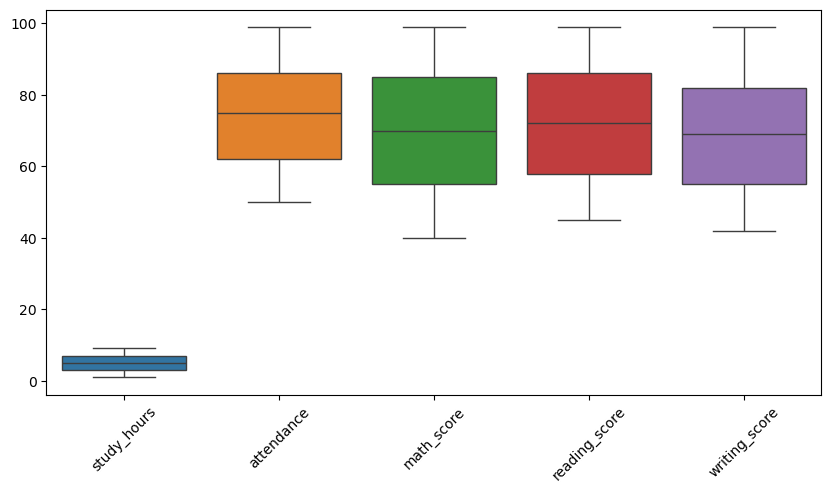

In [12]:
plt.figure(figsize=(10,5))

# Select only numeric columns automatically
numeric_df = df.select_dtypes(include=['number'])

sns.boxplot(data=numeric_df)

plt.xticks(rotation=45)
plt.show()

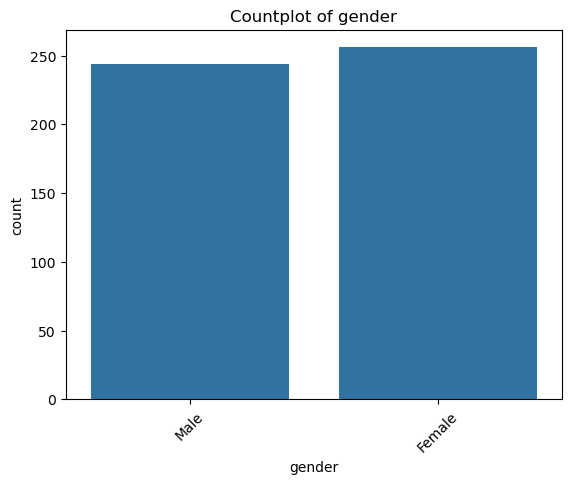

In [14]:
# convert column names to lowercase (safe step)
df.columns = df.columns.str.lower()

# automatically pick a categorical column
cat_col = df.select_dtypes(include='object').columns[0]

sns.countplot(x=cat_col, data=df)

plt.title(f"Countplot of {cat_col}")
plt.xticks(rotation=45)
plt.show()

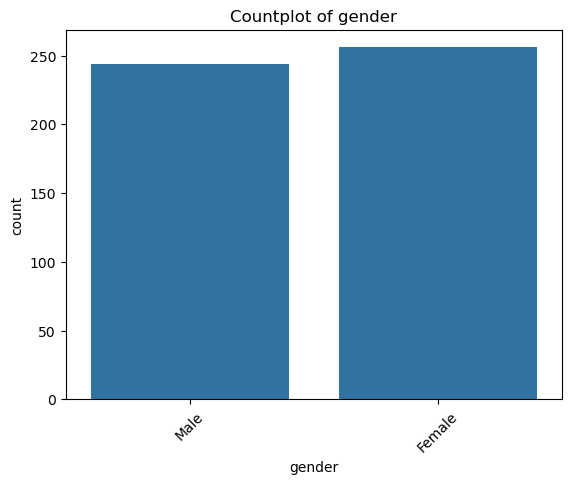

In [16]:
# convert column names to lowercase (safe)
df.columns = df.columns.str.lower()

# automatically pick categorical columns
cat_cols = df.select_dtypes(include='object').columns

# check if at least 2 categorical columns exist
if len(cat_cols) >= 2:
    sns.countplot(x=cat_cols[0], hue=cat_cols[1], data=df)
    plt.title(f"{cat_cols[0]} vs {cat_cols[1]}")
else:
    # fallback: use any column
    col = df.columns[0]
    sns.countplot(x=col, data=df)
    plt.title(f"Countplot of {col}")

plt.xticks(rotation=45)
plt.show()

In [17]:
cat_cols = df.select_dtypes(include='object').columns

if len(cat_cols) >= 2:
    sns.countplot(x=cat_cols[0], hue=cat_cols[1], data=df)
    plt.xticks(rotation=45)
    plt.title(f"{cat_cols[0]} vs {cat_cols[1]}")
    plt.show()

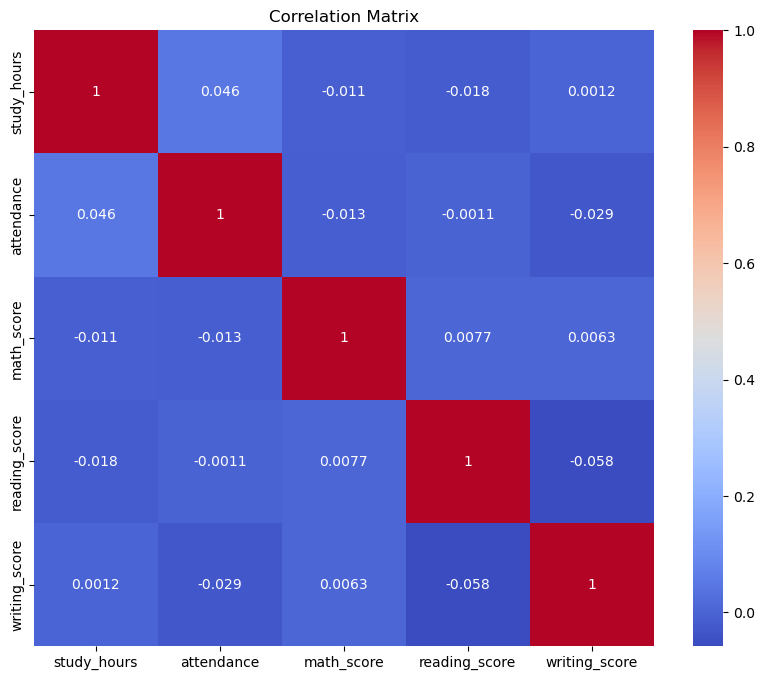

In [18]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

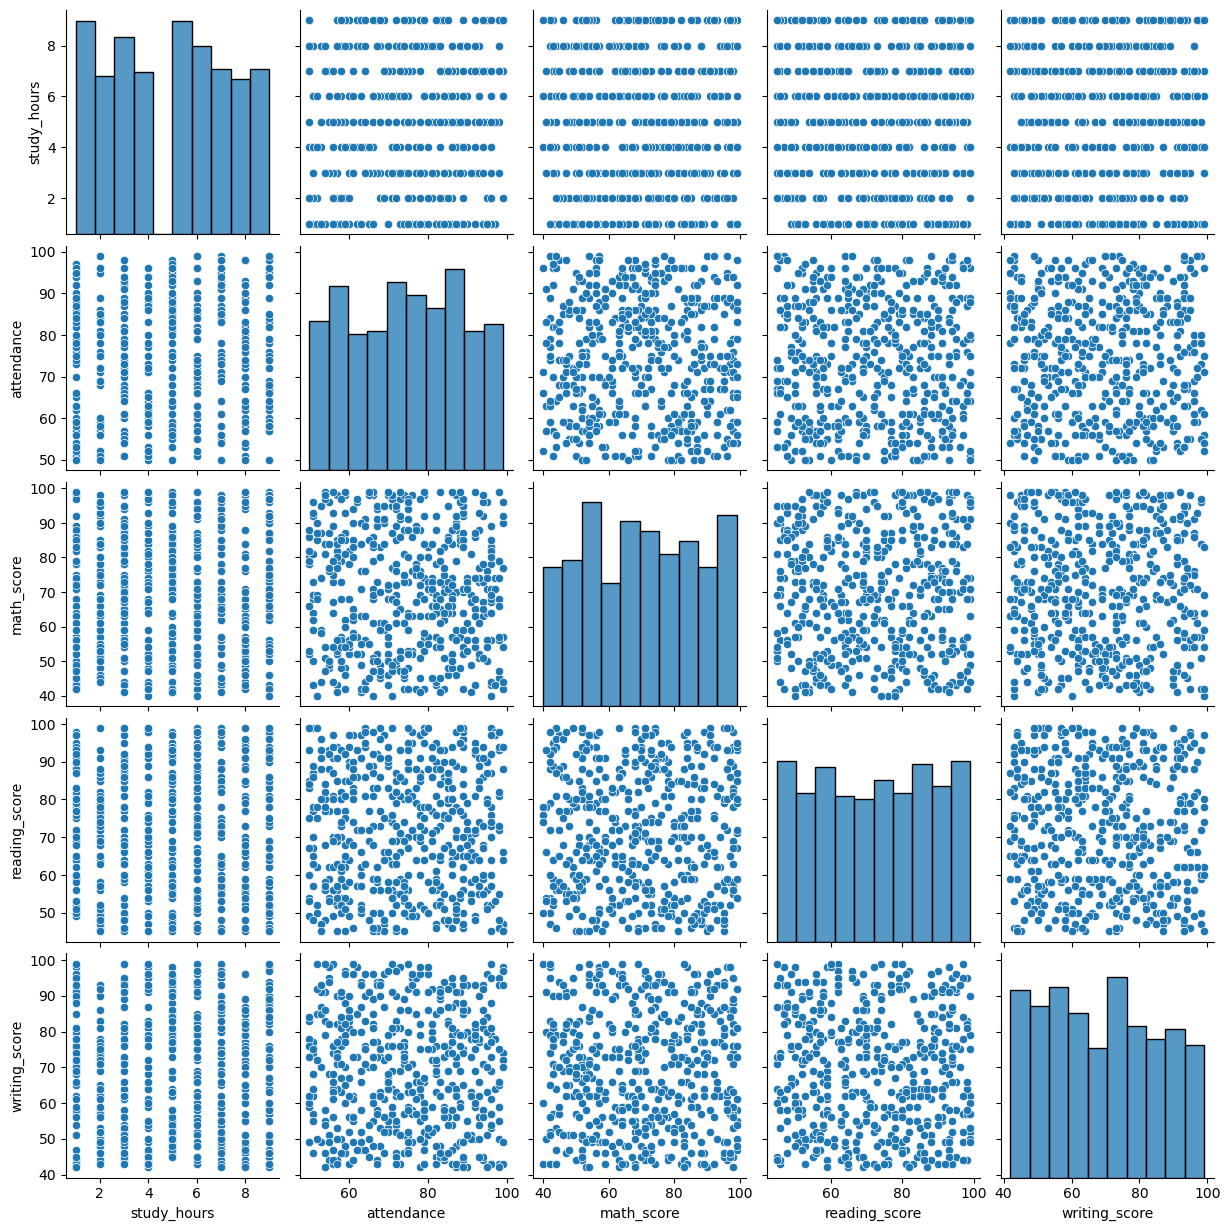

In [19]:
numeric_cols = df.select_dtypes(include='number').columns

if len(numeric_cols) > 1:
    sns.pairplot(df[numeric_cols])
    plt.show()

In [20]:
df.select_dtypes(include='number').skew()

study_hours      0.050288
attendance      -0.044939
math_score       0.018938
reading_score   -0.003079
writing_score    0.093980
dtype: float64

In [21]:
print("Dataset Shape:", df.shape)

numeric_df = df.select_dtypes(include='number')

print("\nMean values:\n", numeric_df.mean())
print("\nMax values:\n", numeric_df.max())
print("\nMin values:\n", numeric_df.min())

Dataset Shape: (500, 6)

Mean values:
 study_hours       4.850
attendance       74.580
math_score       70.204
reading_score    72.066
writing_score    69.042
dtype: float64

Max values:
 study_hours       9
attendance       99
math_score       99
reading_score    99
writing_score    99
dtype: int64

Min values:
 study_hours       1
attendance       50
math_score       40
reading_score    45
writing_score    42
dtype: int64


In [22]:
df.to_csv("eda_processed.csv", index=False)